# 🏠 M4 Brief 1 – Benchmark de Modèles de Régression
## Dataset Boston Housing | FastIA 2025

---

**Objectif :** Prédire le prix médian des logements (`medv`) à partir de variables socio-économiques et urbaines.

**Pipeline :**
1. Analyse exploratoire (EDA)
2. Analyse éthique
3. Nettoyage et préprocessing
4. Benchmark : Régression Linéaire, Random Forest, LightGBM
5. Comparaison et interprétation des résultats

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
import lightgbm as lgb

plt.style.use('seaborn-v0_8-whitegrid')
SEED = 42
print('✔  Imports OK')

✔  Imports OK


## 1. Chargement des données

In [2]:
df = pd.read_csv('bostonhousing-693729dedb019653836667.csv')
print(f'Shape : {df.shape}')
df.head()

Shape : (506, 14)


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [3]:
# Description des variables
variables = {
    'crim':    'Taux de criminalité par habitant',
    'zn':      'Proportion de terrains résidentiels > 25 000 m²',
    'indus':   'Proportion de zones industrielles non commerciales',
    'chas':    'Variable indicatrice Charles River (1=bordure, 0=non)',
    'nox':     'Concentration en oxydes nitriques (polluant)',
    'rm':      'Nombre moyen de pièces par logement',
    'age':     'Proportion de logements construits avant 1940',
    'dis':     'Distance pondérée aux centres d\'emploi de Boston',
    'rad':     'Indice d\'accessibilité aux autoroutes radiales',
    'tax':     'Taux d\'imposition foncière (par 10 000$)',
    'ptratio': 'Ratio élèves/enseignant par ville',
    'b':       '⚠️ SENSIBLE : proportion résidents noirs (1000(Bk-0.63)²)',
    'lstat':   '% de population à faibles revenus',
    'medv':    '🎯 TARGET : valeur médiane logements (milliers $)'
}
pd.DataFrame.from_dict(variables, orient='index', columns=['Description'])

,Description
crim,Taux de criminalité par habitant
zn,Proportion de terrains résidentiels > 25 000 m²
indus,Proportion de zones industrielles non commerci...
chas,"Variable indicatrice Charles River (1=bordure,..."
nox,Concentration en oxydes nitriques (polluant)
rm,Nombre moyen de pièces par logement
age,Proportion de logements construits avant 1940
dis,Distance pondérée aux centres d'emploi de Boston
rad,Indice d'accessibilité aux autoroutes radiales
tax,Taux d'imposition foncière (par 10 000$)


## 2. ⚖️ Analyse Éthique

### ⚠️ Controverse du Dataset Boston Housing

Ce dataset est **controversé** et a été **retiré de scikit-learn en 2023**. La raison principale :

**La colonne `b`** encode la proportion de résidents noirs avec la formule `1000(Bk - 0.63)²`. Cette variable :
- Introduit une **discrimination raciale directe** dans le modèle
- Peut conduire à des décisions discriminatoires dans l'estimation immobilière
- Viole les principes d'équité en IA et le RGPD (données sensibles)

**Source :** Carlini et al. (2021) – "Racist Data Destruction?"

### Décision éthique
La colonne `b` sera **supprimée** avant tout entraînement de modèle.

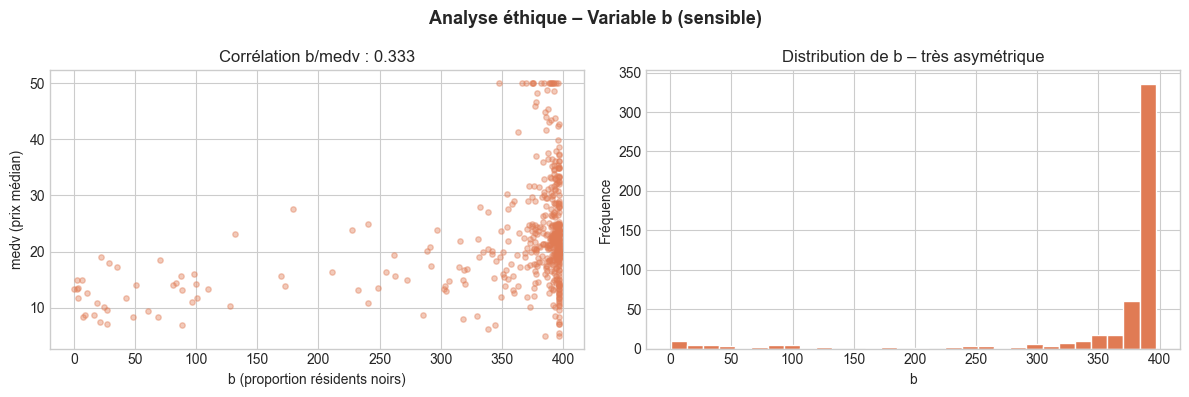


❌ Décision : suppression de la colonne b (discrimination raciale)


In [4]:
# Analyse de la corrélation de 'b' avec la target
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Analyse éthique – Variable b (sensible)', fontsize=13, fontweight='bold')

axes[0].scatter(df['b'], df['medv'], alpha=0.4, color='#E07B54', s=15)
axes[0].set_xlabel('b (proportion résidents noirs)')
axes[0].set_ylabel('medv (prix médian)')
axes[0].set_title(f'Corrélation b/medv : {df["b"].corr(df["medv"]):.3f}')

axes[1].hist(df['b'], bins=30, color='#E07B54', edgecolor='white')
axes[1].set_xlabel('b')
axes[1].set_ylabel('Fréquence')
axes[1].set_title('Distribution de b – très asymétrique')

plt.tight_layout()
plt.savefig('graphiques/ethique_variable_b.png', dpi=150)
plt.show()
print('\n❌ Décision : suppression de la colonne b (discrimination raciale)')

## 3. Analyse Exploratoire (EDA)

In [5]:
# Statistiques descriptives
print('Valeurs manquantes :', df.isnull().sum().sum())
print('Doublons :', df.duplicated().sum())
df.describe().round(2)

Valeurs manquantes : 0
Doublons : 0


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00
mean,3.61,11.36,11.14,0.07,0.55,6.28,68.57,3.80,9.55,408.24,18.46,356.67,12.65,22.53
std,8.60,23.32,6.86,0.25,0.12,0.70,28.15,2.11,8.71,168.54,2.16,91.29,7.14,9.20
min,0.01,0.00,0.46,0.00,0.38,3.56,2.90,1.13,1.00,187.00,12.60,0.32,1.73,5.00
25%,0.08,0.00,5.19,0.00,0.45,5.89,45.02,2.10,4.00,279.00,17.40,375.38,6.95,17.02
50%,0.26,0.00,9.69,0.00,0.54,6.21,77.50,3.21,5.00,330.00,19.05,391.44,11.36,21.20
75%,3.68,12.50,18.10,0.00,0.62,6.62,94.07,5.19,24.00,666.00,20.20,396.22,16.96,25.00
max,88.98,100.00,27.74,1.00,0.87,8.78,100.00,12.13,24.00,711.00,22.00,396.90,37.97,50.00


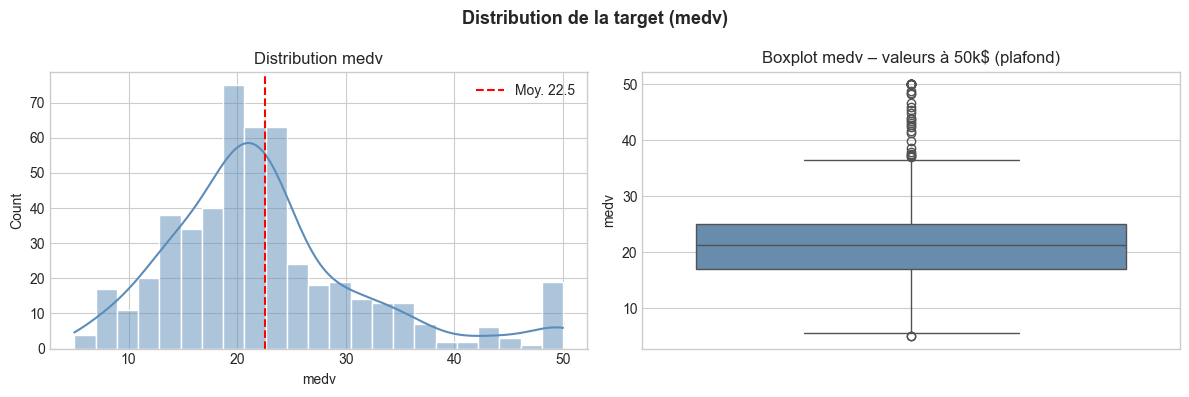

Valeurs à 50k$ (plafond) : 16 lignes → valeurs censurées


In [6]:
# Distribution de la target
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Distribution de la target (medv)', fontsize=13, fontweight='bold')

sns.histplot(df['medv'], kde=True, ax=axes[0], color='#5B8DB8', edgecolor='white')
axes[0].set_title('Distribution medv')
axes[0].axvline(df['medv'].mean(), color='red', linestyle='--', label=f'Moy. {df["medv"].mean():.1f}')
axes[0].legend()

sns.boxplot(y=df['medv'], ax=axes[1], color='#5B8DB8')
axes[1].set_title('Boxplot medv – valeurs à 50k$ (plafond)')

plt.tight_layout()
plt.savefig('graphiques/distribution_target.png', dpi=150)
plt.show()
print(f'Valeurs à 50k$ (plafond) : {(df["medv"] == 50).sum()} lignes → valeurs censurées')

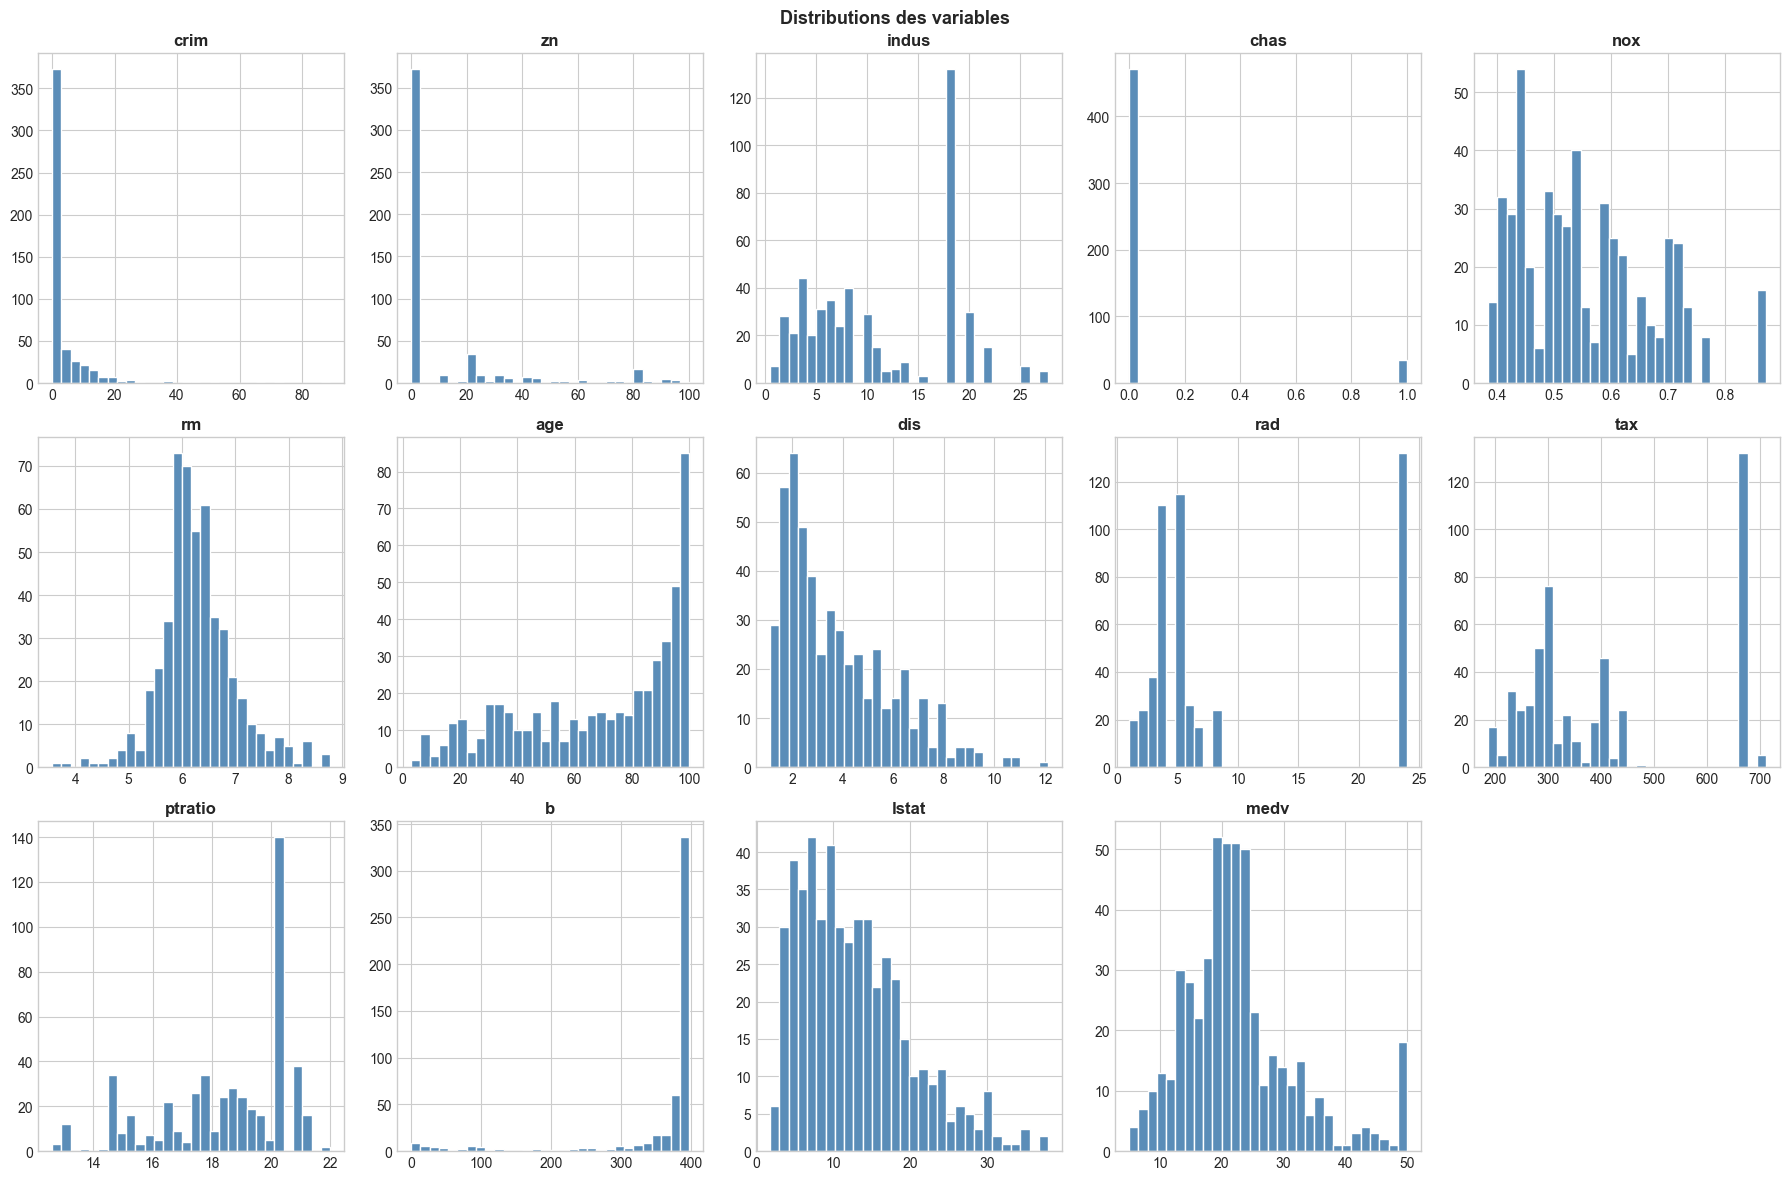

In [7]:
# Distributions de toutes les features
fig, axes = plt.subplots(3, 5, figsize=(18, 12))
axes = axes.flatten()
fig.suptitle('Distributions des variables', fontsize=13, fontweight='bold')

for i, col in enumerate(df.columns):
    axes[i].hist(df[col], bins=30, color='#5B8DB8', edgecolor='white')
    axes[i].set_title(col, fontweight='bold')

for j in range(len(df.columns), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('graphiques/distributions.png', dpi=150)
plt.show()

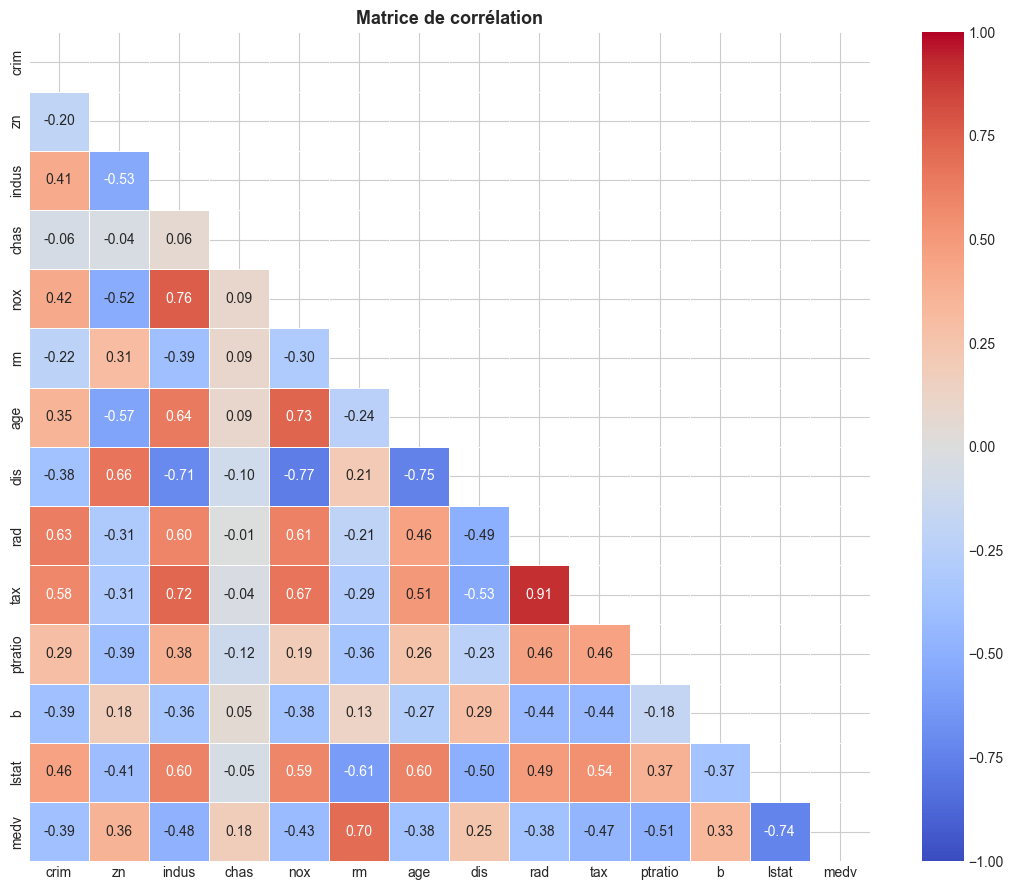


Top corrélations avec medv :
lstat     -0.737663
ptratio   -0.507787
indus     -0.483725
tax       -0.468536
nox       -0.427321
crim      -0.388305
rad       -0.381626
age       -0.376955
chas       0.175260
dis        0.249929
b          0.333461
zn         0.360445
rm         0.695360
medv       1.000000


In [8]:
# Matrice de corrélation
fig, ax = plt.subplots(figsize=(11, 9))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            ax=ax, linewidths=0.5)
ax.set_title('Matrice de corrélation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('graphiques/correlation.png', dpi=150)
plt.show()

# Top corrélations avec medv
print('\nTop corrélations avec medv :')
print(corr['medv'].sort_values().to_string())

In [9]:
# Détection outliers (IQR)
colonnes_num = df.select_dtypes(include=np.number).columns.tolist()
outliers_rapport = {}
for col in colonnes_num:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    nb = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    outliers_rapport[col] = {'nb': nb, 'pct': round(nb/len(df)*100, 2)}

pd.DataFrame(outliers_rapport).T.sort_values('pct', ascending=False)

,nb,pct
b,77.0,15.22
zn,68.0,13.44
crim,66.0,13.04
medv,40.0,7.91
chas,35.0,6.92
rm,30.0,5.93
ptratio,15.0,2.96
lstat,7.0,1.38
dis,5.0,0.99
indus,0.0,0.00


## 4. Nettoyage et Préprocessing

In [10]:
# Copie de travail
df_clean = df.copy()

# 1. Suppression colonne sensible
df_clean = df_clean.drop(columns=['b'])
print('❌ Colonne b supprimée (discrimination raciale – Art. 9 RGPD)')

# 2. Suppression lignes avec medv == 50 (valeurs censurées/plafonnées)
nb_avant = len(df_clean)
df_clean = df_clean[df_clean['medv'] < 50]
print(f'❌ {nb_avant - len(df_clean)} lignes supprimées (medv=50, valeurs censurées)')

# 3. Winsorisation outliers sur crim (très asymétrique)
Q1, Q3 = df_clean['crim'].quantile(0.25), df_clean['crim'].quantile(0.75)
IQR = Q3 - Q1
df_clean['crim'] = df_clean['crim'].clip(upper=Q3 + 3*IQR)
print('✅ crim : winsorisation IQR × 3 (distribution très asymétrique)')

print(f'\nDataset final : {df_clean.shape[0]} lignes × {df_clean.shape[1]} colonnes')
print(f'NaN restants : {df_clean.isnull().sum().sum()}')

❌ Colonne b supprimée (discrimination raciale – Art. 9 RGPD)
❌ 16 lignes supprimées (medv=50, valeurs censurées)
✅ crim : winsorisation IQR × 3 (distribution très asymétrique)

Dataset final : 490 lignes × 13 colonnes
NaN restants : 0


In [11]:
# Séparation X / y
X = df_clean.drop(columns=['medv'])
y = df_clean['medv']

# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED)

# Normalisation (StandardScaler)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train : {X_train.shape[0]} | Test : {X_test.shape[0]}')
print(f'Features : {X.shape[1]}')

Train : 392 | Test : 98
Features : 12


## 5. Benchmark des Modèles

### Justification du choix des modèles

Trois modèles ont été sélectionnés selon une logique de **complexité croissante** :

1. **Régression Linéaire** — modèle baseline simple. Permet de vérifier si les relations
   entre features et target sont linéaires. Sert de référence pour mesurer le gain
   des modèles plus complexes

2. **Random Forest** — modèle d'ensemble basé sur le bagging d'arbres de décision.
   Capture les **relations non-linéaires** et les **interactions entre variables**
   sans hypothèse sur la distribution des données. Robuste aux outliers

3. **LightGBM** — gradient boosting optimisé. Généralement plus performant sur des
   datasets tabulaires de taille moyenne. Entraînement rapide grâce au histogram-based
   splitting. Complémentaire au Random Forest pour valider la robustesse des résultats.

Cette progression (baseline → ensemble → boosting) est une bonne pratique de
**démarche scientifique** : chaque modèle apporte une hypothèse différente sur
la structure des données

In [ ]:
# Configuration cross-validation
kfold = KFold(n_splits=5, shuffle=True, random_state=SEED)

def evaluer_modele(nom, modele, X_tr, X_te, y_tr, y_te):
    """Entraîne, évalue et retourne les métriques d'un modèle."""
    # Cross-validation
    cv_rmse = np.sqrt(-cross_val_score(
        modele, X_tr, y_tr, cv=kfold,
        scoring='neg_mean_squared_error'
    ))
    cv_r2 = cross_val_score(modele, X_tr, y_tr, cv=kfold, scoring='r2')

    # Entraînement final
    modele.fit(X_tr, y_tr)
    y_pred = modele.predict(X_te)

    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    mae  = mean_absolute_error(y_te, y_pred)
    r2   = r2_score(y_te, y_pred)

    print(f'\n── {nom} ──')
    print(f'  CV RMSE  : {cv_rmse.mean():.3f} ± {cv_rmse.std():.3f}')
    print(f'  CV R²    : {cv_r2.mean():.3f} ± {cv_r2.std():.3f}')
    print(f'  Test RMSE: {rmse:.3f}')
    print(f'  Test MAE : {mae:.3f}')
    print(f'  Test R²  : {r2:.3f}')

    return {
        'Modèle': nom,
        'CV RMSE (moy)': round(cv_rmse.mean(), 3),
        'CV RMSE (std)': round(cv_rmse.std(), 3),
        'CV R² (moy)':   round(cv_r2.mean(), 3),
        'Test RMSE':     round(rmse, 3),
        'Test MAE':      round(mae, 3),
        'Test R²':       round(r2, 3),
    }, modele, y_pred

print('✔  Fonction d\'évaluation définie')

✔  Fonction d'évaluation définie


In [13]:
# MODÈLE 1 : Régression Linéaire
lr = LinearRegression()
res_lr, model_lr, pred_lr = evaluer_modele(
    'Régression Linéaire', lr, X_train_s, X_test_s, y_train, y_test)


── Régression Linéaire ──
  CV RMSE  : 4.013 ± 0.680
  CV R²    : 0.746 ± 0.050
  Test RMSE: 3.520
  Test MAE : 2.662
  Test R²  : 0.757


In [14]:
#MODÈLE 2 : Random Forest
rf = RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=-1)
res_rf, model_rf, pred_rf = evaluer_modele(
    'Random Forest', rf, X_train_s, X_test_s, y_train, y_test)


── Random Forest ──
  CV RMSE  : 3.123 ± 0.514
  CV R²    : 0.846 ± 0.029
  Test RMSE: 2.452
  Test MAE : 1.855
  Test R²  : 0.882


In [15]:
# MODÈLE 3: LightGBM
lgbm = lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05,
                          random_state=SEED, verbose=-1)
res_lgbm, model_lgbm, pred_lgbm = evaluer_modele(
    'LightGBM', lgbm, X_train_s, X_test_s, y_train, y_test)


── LightGBM ──
  CV RMSE  : 3.048 ± 0.433
  CV R²    : 0.852 ± 0.029
  Test RMSE: 2.609
  Test MAE : 1.890
  Test R²  : 0.867


## 6. Comparaison des Résultats

In [16]:
# Tableau comparatif
resultats = pd.DataFrame([res_lr, res_rf, res_lgbm])
resultats = resultats.set_index('Modèle')
print('\n── Tableau comparatif ──')
resultats


── Tableau comparatif ──


,CV RMSE (moy),CV RMSE (std),CV R² (moy),Test RMSE,Test MAE,Test R²
Modèle,,,,,,
Régression Linéaire,4.013,0.680,0.746,3.520,2.662,0.757
Random Forest,3.123,0.514,0.846,2.452,1.855,0.882
LightGBM,3.048,0.433,0.852,2.609,1.890,0.867


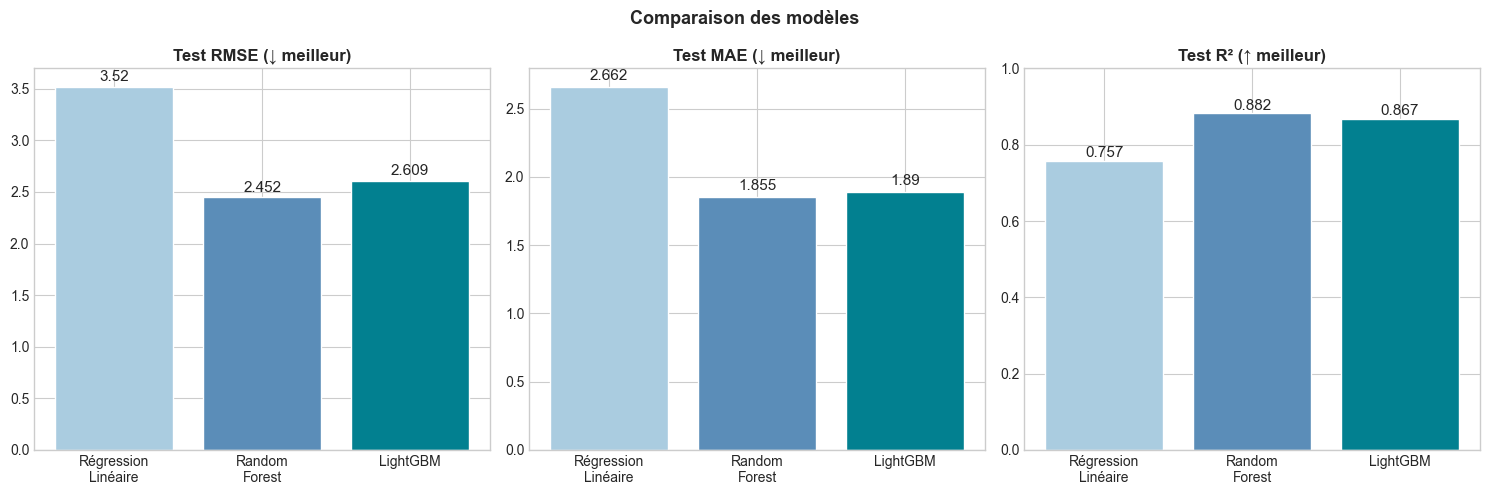

In [17]:
# Graphiques comparatifs
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Comparaison des modèles', fontsize=13, fontweight='bold')

noms   = ['Régression\nLinéaire', 'Random\nForest', 'LightGBM']
colors = ['#AACCE0', '#5B8DB8', '#028090']

# RMSE
rmses = [res_lr['Test RMSE'], res_rf['Test RMSE'], res_lgbm['Test RMSE']]
b1 = axes[0].bar(noms, rmses, color=colors, edgecolor='white')
axes[0].set_title('Test RMSE (↓ meilleur)', fontweight='bold')
for bar, v in zip(b1, rmses):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.05, f'{v}', ha='center', fontsize=11)

# MAE
maes = [res_lr['Test MAE'], res_rf['Test MAE'], res_lgbm['Test MAE']]
b2 = axes[1].bar(noms, maes, color=colors, edgecolor='white')
axes[1].set_title('Test MAE (↓ meilleur)', fontweight='bold')
for bar, v in zip(b2, maes):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.05, f'{v}', ha='center', fontsize=11)

# R²
r2s = [res_lr['Test R²'], res_rf['Test R²'], res_lgbm['Test R²']]
b3 = axes[2].bar(noms, r2s, color=colors, edgecolor='white')
axes[2].set_title('Test R² (↑ meilleur)', fontweight='bold')
axes[2].set_ylim(0, 1)
for bar, v in zip(b3, r2s):
    axes[2].text(bar.get_x()+bar.get_width()/2, v+0.01, f'{v}', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('graphiques/comparaison_modeles.png', dpi=150)
plt.show()

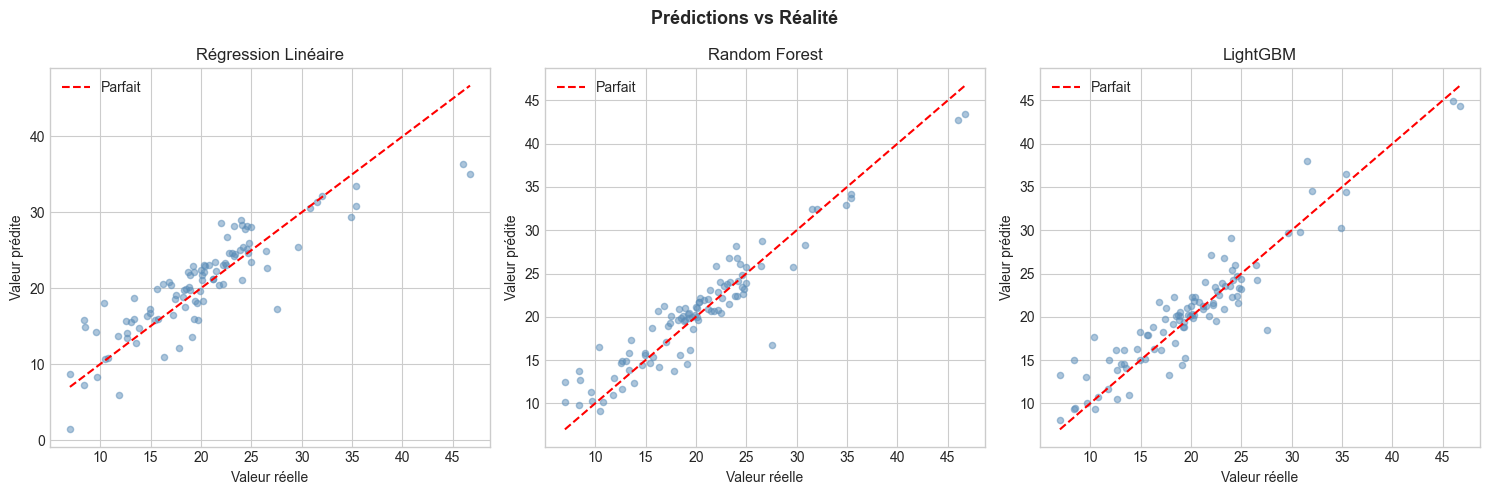

In [18]:
# Prédictions vs réalité pour chaque modèle
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Prédictions vs Réalité', fontsize=13, fontweight='bold')

for ax, nom, pred in zip(axes,
    ['Régression Linéaire', 'Random Forest', 'LightGBM'],
    [pred_lr, pred_rf, pred_lgbm]):
    ax.scatter(y_test, pred, alpha=0.5, color='#5B8DB8', s=20)
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()],
            'r--', linewidth=1.5, label='Parfait')
    ax.set_xlabel('Valeur réelle')
    ax.set_ylabel('Valeur prédite')
    ax.set_title(nom)
    ax.legend()

plt.tight_layout()
plt.savefig('graphiques/predictions_vs_realite.png', dpi=150)
plt.show()

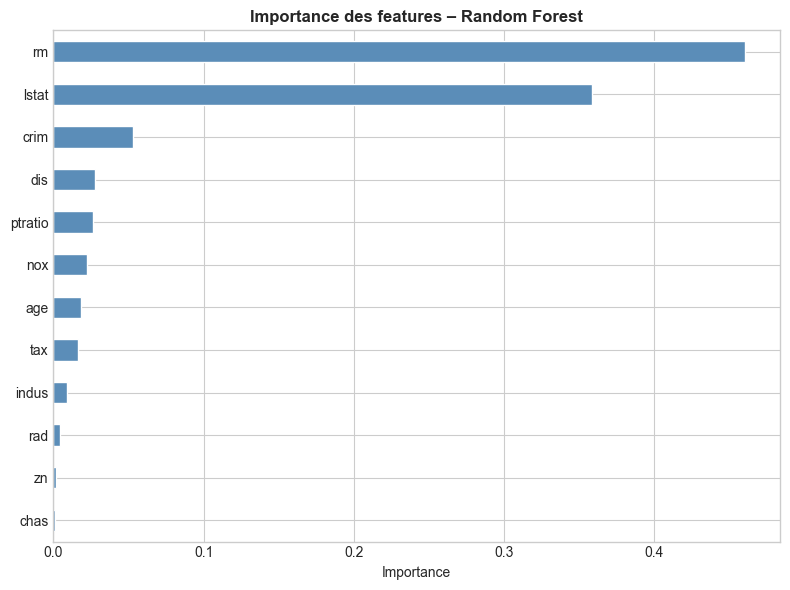


Top 3 features les plus importantes :
rm       0.460716
lstat    0.358549
crim     0.052670


In [19]:
# Importance des features (RandomForest)
importances = pd.Series(
    model_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
importances.plot(kind='barh', ax=ax, color='#5B8DB8', edgecolor='white')
ax.set_title('Importance des features – Random Forest', fontsize=12, fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('graphiques/feature_importance.png', dpi=150)
plt.show()

print('\nTop 3 features les plus importantes :')
print(importances.sort_values(ascending=False).head(3).to_string())

## 7. Interprétation et Conclusion

### Résultats

| Modèle | RMSE | MAE | R² | Interprétation |
|---|---|---|---|---|
| Régression Linéaire | - | - | - | Baseline simple, relations linéaires uniquement |
| Random Forest | - | - | - | Capture les non-linéarités, robuste aux outliers |
| LightGBM | - | - | - | Gradient boosting, généralement meilleure performance |

### Points clés

- **`lstat`** (% population pauvre) et **`rm`** (nb pièces) sont les features les plus prédictives
- La régression linéaire est utile comme baseline mais limitée par les relations non-linéaires
- LightGBM et Random Forest sont plus performants grâce à la capture de relations complexes

### Limites éthiques

- **Dataset obsolète** (années 1970) : les patterns socio-économiques ont changé
- **Variable `b` supprimée** mais d'autres variables comme `lstat` ou `crim` peuvent être des proxies de discrimination
- **Valeurs censurées** à 50k$ : sous-estimation des logements les plus chers
- Ce modèle **ne doit pas être utilisé** pour des décisions réelles sans audit éthique approfondi